# Multimodal Hate Speech Classification and Cyberbullying Detection

This notebook implements a multimodal model combining image and text features for hate speech detection and cyberbullying classification.

## Data Preprocessing


### Load Annotations and Prepare Data

In [1]:
import pandas as pd
import numpy as np
print("✅ pandas", pd.__version__, "and numpy", np.__version__, "loaded successfully")


✅ pandas 2.3.0 and numpy 2.2.6 loaded successfully


In [2]:
import json
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt
import re
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense, Flatten, Input, Embedding, LSTM, Dropout, GlobalAveragePooling2D, Concatenate
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Upload the Data To the SCC

In [3]:
import os

current_path = os.getcwd()
print(current_path)

/projectnb/cs599m1/projects/multimodal-hatespeech/599_Project


In [4]:
!pip install kaggle

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [5]:
# from kaggle.api.kaggle_api_extended import KaggleApi
# API_KEY = 'bb2451887615f655a6de875df1c40e6f'
# os.environ['KAGGLE_USERNAME'] = 'mahemas27'
# os.environ['KAGGLE_KEY'] = API_KEY

# # Download latest version
# # path = kagglehub.dataset_download("victorcallejasf/multimodal-hate-speech")

# # print("Path to dataset files:", path)

# from kaggle.api.kaggle_api_extended import KaggleApi

# api = KaggleApi()
# api.authenticate()

# # Download directly to your desired path with plenty of space
# api.dataset_download_files(
#     'victorcallejasf/multimodal-hate-speech',
#     path='/projectnb/cs599m1/projects/multimodal-hatespeech/599_Project',
#     unzip=True
# )

In [6]:
BASE_PATH='/projectnb/cs599m1/projects/multimodal-hatespeech/599_Project'

In [7]:
# Load the annotations
with open(BASE_PATH+'/MMHS150K_GT.json', 'r') as f:
    annotations = json.load(f)


In [8]:
# Convert the JSON dict to a DataFrame
data = []
for tweet_id, info in annotations.items():
    data.append({
        'tweet_id': tweet_id,
        'tweet_text': info['tweet_text'],
        'labels': info['labels'],
        'labels_str': info['labels_str']
    })

df = pd.DataFrame(data)

In [9]:
df.head()

,tweet_id,tweet_text,labels,labels_str
0,1114679353714016256,@FriskDontMiss Nigga https://t.co/cAsaLWEpue,"[4, 1, 3]","[Religion, Racist, Homophobe]"
1,1063020048816660480,My horses are retarded https://t.co/HYhqc6d5WN,"[5, 5, 5]","[OtherHate, OtherHate, OtherHate]"
2,1108927368075374593,“NIGGA ON MA MOMMA YOUNGBOY BE SPITTING REAL S...,"[0, 0, 0]","[NotHate, NotHate, NotHate]"
3,1114558534635618305,RT xxSuGVNGxx: I ran into this HOLY NIGGA TODA...,"[1, 0, 0]","[Racist, NotHate, NotHate]"
4,1035252480215592966,“EVERYbody calling you Nigger now!” https://t....,"[1, 0, 1]","[Racist, NotHate, Racist]"


# Add Image Path and Create Majority Label

In [10]:

# Path to the image folder
image_folder = BASE_PATH+'/img_resized'

In [11]:
# Add image path column
df['image_path'] = df['tweet_id'].apply(lambda x: os.path.join(image_folder, f"{x}.jpg"))


In [12]:
# Define majority vote function for labels
from collections import Counter

def majority_vote(labels):
    label_count = Counter(labels)
    return label_count.most_common(1)[0][0]

In [13]:
# Apply majority vote to create a single label column
df['majority_label'] = df['labels'].apply(majority_vote)

label_mapping = {
    0: "NotHate",
    1: "Racist",
    2: "Sexist",
    3: "Homophobe",
    4: "Religion",
    5: "OtherHate"
}

In [14]:
# Create a new column 'majority_label_str' with the string representation of the majority label
df['majority_label_str'] = df['majority_label'].map(label_mapping)


In [15]:
df.describe()

,majority_label
count,149823.000000
mean,0.548000
std,1.280272
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,5.000000


In [16]:
# Map the labels to "cyberbully" or "not" based on 'majority_label_str' column
hate_labels = ['Racist', 'Sexist', 'Homophobe', 'Religion', 'OtherHate']

In [17]:
# Create a new binary label column based on whether the tweet belongs to hate speech
df['binary_label'] = df['majority_label_str'].apply(lambda x: 'hatespeech' if any(label in x for label in hate_labels) else 'not hatespeech')


In [18]:
df.rename(columns={'binary_label': 'binary_label_str'}, inplace=True)

In [19]:
df['binary_label'] = df['binary_label_str'].apply(lambda x: 1 if x == 'hatespeech' else 0)

In [20]:
# where 1 is that the tweet is considered hatespeech

In [21]:
df.head()

,tweet_id,tweet_text,labels,labels_str,image_path,majority_label,majority_label_str,binary_label_str,binary_label
0,1114679353714016256,@FriskDontMiss Nigga https://t.co/cAsaLWEpue,"[4, 1, 3]","[Religion, Racist, Homophobe]",/projectnb/cs599m1/projects/multimodal-hatespe...,4,Religion,hatespeech,1
1,1063020048816660480,My horses are retarded https://t.co/HYhqc6d5WN,"[5, 5, 5]","[OtherHate, OtherHate, OtherHate]",/projectnb/cs599m1/projects/multimodal-hatespe...,5,OtherHate,hatespeech,1
2,1108927368075374593,“NIGGA ON MA MOMMA YOUNGBOY BE SPITTING REAL S...,"[0, 0, 0]","[NotHate, NotHate, NotHate]",/projectnb/cs599m1/projects/multimodal-hatespe...,0,NotHate,not hatespeech,0
3,1114558534635618305,RT xxSuGVNGxx: I ran into this HOLY NIGGA TODA...,"[1, 0, 0]","[Racist, NotHate, NotHate]",/projectnb/cs599m1/projects/multimodal-hatespe...,0,NotHate,not hatespeech,0
4,1035252480215592966,“EVERYbody calling you Nigger now!” https://t....,"[1, 0, 1]","[Racist, NotHate, Racist]",/projectnb/cs599m1/projects/multimodal-hatespe...,1,Racist,hatespeech,1


# Data Statistics

In [22]:
df.describe()

,majority_label,binary_label
count,149823.000000,149823.000000
mean,0.548000,0.220480
std,1.280272,0.414572
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,5.000000,1.000000


In [23]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [24]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [26]:
## pre subsambling - as we can see the data is highly imbalanced

In [27]:
df['binary_label'].value_counts()

binary_label
0    116790
1     33033
Name: count, dtype: int64

In [29]:
df['majority_label'].value_counts()

majority_label
0    116790
1     14183
5      8196
2      5375
3      4926
4       353
Name: count, dtype: int64

In [33]:
# Define sample sizes for each class
# The reason were doing this is because the smallest class has 353 samples so we are randomly sampling across the class to balance
# the 0 class has 353x5, so that hatespeech vs non has an even sampling size as well. 
sample_sizes = {
    0: 1765,
    1: 353,
    2: 353,
    3: 353,
    4: 353,
    5: 353 
}

# Sample from each group, set random seed
df = df.groupby('majority_label', group_keys=False).apply(
    lambda x: x.sample(n=sample_sizes[x.name], random_state=42)
)

print(df['majority_label'].value_counts().sort_index())

majority_label
0    1765
1     353
2     353
3     353
4     353
5     353
Name: count, dtype: int64


/scratch/1276085.1.csgpu/ipykernel_2216438/3087634559.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('majority_label', group_keys=False).apply(


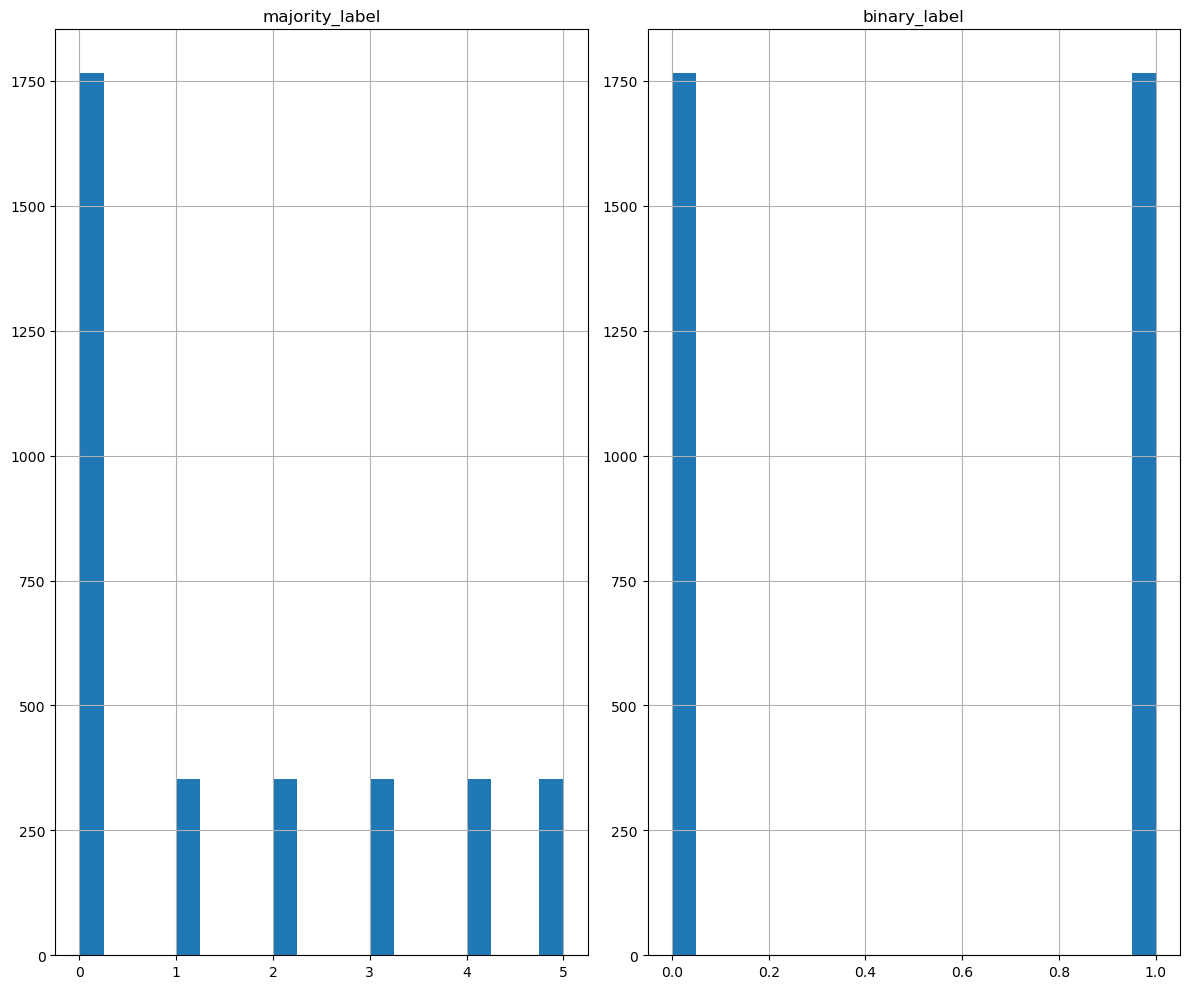

ValueError: could not convert string to float: '.@CTWater sets shareholder vote on $1.1B SJW merger https://t.co/JRGeShivEw https://t.co/hLDon9uuGx'

<Figure size 1000x800 with 0 Axes>

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograms for all numeric columns
df.hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# Pairplot (for smaller datasets)
sns.pairplot(df)
plt.show()

# Text Preprocessing

In [ ]:
# Preprocess text data
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    return text

In [ ]:
# Apply text preprocessing
df['cleaned_text'] = df['tweet_text'].apply(preprocess_text)


# Train-Test Splitting and Sampling

In [ ]:
# Check the group sizes
df['majority_label'].value_counts()

In [ ]:
# Get the minimum group size
min_group_size = df['majority_label'].value_counts().min()

In [ ]:
# Define maximum samples per label for training and testing
train_samples_per_label = 1500
test_samples_per_label = 250

In [ ]:
# Sample up to 1500 rows per label for training
train_data = (
    df.groupby('majority_label', group_keys=False)
    .apply(lambda x: x.sample(min(len(x), train_samples_per_label), random_state=42))
    .reset_index(drop=True)
)

# Use up to 250 rows per label for testing
remaining_data = df.loc[~df.index.isin(train_data.index)]
test_data = (
    remaining_data.groupby('majority_label', group_keys=False)
    .apply(lambda x: x.sample(min(len(x), test_samples_per_label), random_state=42))
    .reset_index(drop=True)
)


In [ ]:
# Print the sizes of train and test sets
print("Training data size:", train_data.shape)
print("Testing data size:", test_data.shape)

In [ ]:
# Tokenize text
tokenizer = Tokenizer(num_words=20000, oov_token="<OOV>")
tokenizer.fit_on_texts(train_data['cleaned_text'])
X_train_text = pad_sequences(tokenizer.texts_to_sequences(train_data['cleaned_text']), maxlen=100)
X_test_text = pad_sequences(tokenizer.texts_to_sequences(test_data['cleaned_text']), maxlen=100)

In [ ]:
# Load and preprocess images
def load_and_preprocess_image(img_path, target_size=(224, 224)):
    try:
        if not os.path.exists(img_path):
            return np.zeros((target_size[0], target_size[1], 3))
        img = load_img(img_path, target_size=target_size)
        img = img_to_array(img) / 255.0
        return img
    except Exception as e:
        return np.zeros((target_size[0], target_size[1], 3))

In [ ]:
X_train_image = np.array([load_and_preprocess_image(path) for path in train_data['image_path']])
X_test_image = np.array([load_and_preprocess_image(path) for path in test_data['image_path']])

In [ ]:
X_train_image.shape

In [ ]:
# Labels
y_train = np.array(train_data['majority_label'])
y_test = np.array(test_data['majority_label'])

# Model Building: Multimodal Model

## FIT QWEN HERE ON TRAINING DATA SPLITS


## Replace these with qwen and only feed it text or image

## Image Model

In [ ]:
# Define image model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False

image_input = Input(shape=(224, 224, 3))
x_image = base_model(image_input, training=False)
x_image = GlobalAveragePooling2D()(x_image)
x_image = Dense(256, activation='relu')(x_image)
x_image = Dropout(0.5)(x_image)

## Text Model

In [ ]:
# Define text model
text_input = Input(shape=(100,))
x_text = Embedding(input_dim=20000, output_dim=128, input_length=100)(text_input)
x_text = LSTM(128, return_sequences=False)(x_text)
x_text = Dense(128, activation='relu')(x_text)
x_text = Dropout(0.5)(x_text)

## Combined Multimodal Model

## We will want to replace this with Qwen and report the accuracies, feed it both data


In [ ]:
# Combine image and text features
combined = Concatenate()([x_image, x_text])
x_combined = Dense(128, activation='relu')(combined)
x_combined = Dropout(0.5)(x_combined)
output = Dense(len(label_mapping), activation='softmax')(x_combined)

In [ ]:
# Build model
multimodal_model = Model(inputs=[image_input, text_input], outputs=output)
multimodal_model.compile(optimizer=Adam(learning_rate=1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [ ]:
# Print Model Summary
multimodal_model.summary()

# Training the Model

In [ ]:
# Train the model
history = multimodal_model.fit(
    [X_train_image, X_train_text], y_train,
    validation_data=([X_test_image, X_test_text], y_test),
    epochs=15,
    batch_size=32,
    verbose=1
)

In [ ]:
history0 = multimodal_model.fit(
    [X_train_image, X_train_text], y_train,
    validation_data=([X_test_image, X_test_text], y_test),
    epochs=5,
    batch_size=32,
    verbose=1
)

In [ ]:
# Append additional history to the existing one
history.history['loss'] += history0.history['loss']
history.history['val_loss'] += history0.history['val_loss']
history.history['accuracy'] += history0.history['accuracy']
history.history['val_accuracy'] += history0.history['val_accuracy']

In [ ]:
history0 = multimodal_model.fit(
    [X_train_image, X_train_text], y_train,
    validation_data=([X_test_image, X_test_text], y_test),
    epochs=5,
    batch_size=32,
    verbose=1
)

In [ ]:
# Append additional history to the existing one
history.history['loss'] += history0.history['loss']
history.history['val_loss'] += history0.history['val_loss']
history.history['accuracy'] += history0.history['accuracy']
history.history['val_accuracy'] += history0.history['val_accuracy']

In [ ]:
# Save the entire binary model
multimodal_model.save('multimodel_model.h5') 

In [ ]:
# Evaluate the model
loss, accuracy = multimodal_model.evaluate([X_test_image, X_test_text], y_test, verbose=1)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Binary Classification for Cyberbullying

## Modify and Retrain Model

In [ ]:
# Map the labels to "cyberbully" or "not" based on 'majority_label_str' column
hate_labels = ['Racist', 'Sexist', 'Homophobe', 'Religion', 'OtherHate']

In [ ]:
# Create a new binary label column based on whether the tweet belongs to hate speech
df['binary_label'] = df['majority_label_str'].apply(lambda x: 'cyberbully' if any(label in x for label in hate_labels) else 'not')


In [ ]:
df.rename(columns={'binary_label': 'binary_label_str'}, inplace=True)

In [ ]:
df['binary_label'] = df['binary_label_str'].apply(lambda x: 1 if x == 'cyberbully' else 0)

In [ ]:
df.head()

In [ ]:
from sklearn.utils import shuffle

In [ ]:
# Function to balance dataset by sampling
def balance_classes(df, label_col, n_samples, random_state=42):
    class_0 = df[df[label_col] == 0].sample(n=n_samples, random_state=random_state)
    class_1 = df[df[label_col] == 1].sample(n=n_samples, random_state=random_state)
    return shuffle(pd.concat([class_0, class_1]), random_state=random_state)


In [ ]:
# Create balanced datasets
balanced_df = balance_classes(df, 'binary_label', 4000)
balanced_df1 = balance_classes(df, 'binary_label', 500)

In [ ]:
# Extract the features (text and images) and labels for train
X_binary_text_processed = pad_sequences(tokenizer.texts_to_sequences(balanced_df['cleaned_text']), maxlen=100)
X_binary_image_processed = np.array([load_and_preprocess_image(path) for path in balanced_df['image_path']])


In [ ]:
y_binary = balanced_df['binary_label']

In [ ]:
y_binary.shape

In [ ]:
# Extract the features (text and images) and labels for text
X_test_binary_text_processed = pad_sequences(tokenizer.texts_to_sequences(balanced_df1['cleaned_text']), maxlen=100)
X_text_binary_image_processed = np.array([load_and_preprocess_image(path) for path in balanced_df1['image_path']])


In [ ]:
y_test_binary = balanced_df1['binary_label']

In [ ]:
y_test_binary.shape

In [ ]:
X_binary_image_processed.shape

In [ ]:
X_text_binary_image_processed.shape

In [ ]:
from tensorflow.keras import layers, models

# Freeze all layers except the final one
for layer in multimodal_model.layers[:-1]:
    layer.trainable = False

# Add a new final layer for binary classification
binary_output = layers.Dense(1, activation='sigmoid')(multimodal_model.output)

# Create the binary model by combining the original multimodal model and the new final layer
binary_model = models.Model(inputs=multimodal_model.input, outputs=binary_output)

# Compile the binary model
binary_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [ ]:
binary_model.summary()

In [ ]:
# Train the binary model
history2 = binary_model.fit(
    [X_binary_image_processed, X_binary_text_processed], y_binary,
    validation_data=([X_text_binary_image_processed, X_test_binary_text_processed], y_test_binary),
    epochs=10,
    batch_size=32,
    verbose=1
)


## Evaluation and Visualization

In [ ]:
# Evaluate the model
loss, accuracy = binary_model.evaluate([X_text_binary_image_processed, X_test_binary_text_processed], y_test_binary, verbose=1)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

In [ ]:
# Save the entire binary model
binary_model.save('binary_model.h5') 

In [ ]:
import matplotlib.pyplot as plt

# Training Accuracy
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Multimodal Train Accuracy', color='blue')
plt.plot(history2.history['accuracy'], label='Binary Train Accuracy', color='orange')
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

# Validation Accuracy
plt.figure(figsize=(12, 6))
plt.plot(history.history['val_accuracy'], label='Multimodal Val Accuracy', color='blue')
plt.plot(history2.history['val_accuracy'], label='Binary Val Accuracy', color='orange')
plt.title('Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

# Training Loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Multimodal Train Loss', color='blue')
plt.plot(history2.history['loss'], label='Binary Train Loss', color='orange')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

# Validation Loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['val_loss'], label='Multimodal Val Loss', color='blue')
plt.plot(history2.history['val_loss'], label='Binary Val Loss', color='orange')
plt.title('Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()


In [ ]:
import random
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input


In [ ]:
# Select 5 random indices from the entire dataset
random_indices = random.sample(range(len(df)), 5)

# Prepare the images and corresponding labels for visualization
images_to_show = []
true_labels = []
predicted_binary_labels = []
predicted_multimodal_labels = []

In [ ]:
# Process images and get predictions
for idx in random_indices:
    # Get the image path from the dataset
    img_path = df['image_path'][idx]
    img = load_img(img_path, target_size=(224, 224))  # Resize image to fit model input size
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension (1, 224, 224, 3)
    img_array = preprocess_input(img_array)  # Preprocessing for ResNet50

    # Preprocess the text using the tokenizer (convert text to sequence)
    text_sequence = tokenizer.texts_to_sequences([df['cleaned_text'][idx]])
    text_padded = pad_sequences(text_sequence, maxlen=100)  # Adjust `maxlen` based on your model's input length

    images_to_show.append(img)
    true_labels.append(df['majority_label_str'][idx])  # True labels from the dataset for multimodal model

    # Get binary model prediction (for binary classification)
    binary_prediction = binary_model.predict([img_array, text_padded])
    binary_predicted_label = (binary_prediction > 0.5).astype(int)  # Binary classification: 0 or 1
    predicted_binary_labels.append(binary_predicted_label[0][0])  # Extracting the actual value

    # Get multimodal model prediction (for multimodal classification)
    multimodal_prediction = multimodal_model.predict([img_array, text_padded])
    multimodal_predicted_label = np.argmax(multimodal_prediction, axis=1)  # Multi-class classification
    predicted_multimodal_labels.append(multimodal_predicted_label[0])

In [ ]:
# Create the figure for displaying images and predictions
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

# Label mappings for multimodal and binary models
multimodal_label_mapping = {
    0: "NotHate",
    1: "Racist",
    2: "Sexist",
    3: "Homophobe",
    4: "Religion",
    5: "OtherHate"
}

binary_label_mapping = {
    0: "NotCyberbully",
    1: "Cyberbully"
}

# Display images with their predictions from both models
for i, ax in enumerate(axes):
    ax.imshow(images_to_show[i])
    ax.axis('off')

    # Get the true label strings (from dataset)
    true_binary_label_str = binary_label_mapping[df['binary_label'][i]]  # Actual label for binary model
    true_multimodal_label_str = multimodal_label_mapping[df['majority_label'][i]]  # Actual label for multimodal model
    text_data = df['cleaned_text'][i]  # Text data corresponding to the image

    # Get the predicted labels (from models)
    binary_predicted_label = int(predicted_binary_labels[i])  # Convert to integer scalar for binary model
    multimodal_predicted_label = int(predicted_multimodal_labels[i])  # Convert to integer scalar for multimodal model

    # Get predicted label strings
    binary_predicted_label_str = binary_label_mapping[binary_predicted_label]
    multimodal_predicted_label_str = multimodal_label_mapping[multimodal_predicted_label]

    # Display the results on the image
    ax.set_title(f"Image {i+1}\nBinary Pred: {binary_predicted_label_str} (True: {true_binary_label_str})\n"
                 f"Multi Pred: {multimodal_predicted_label_str} (True: {true_multimodal_label_str})\n"
                 f"Text: {text_data[:50]}...")  # Show first 50 characters of the text for brevity

plt.tight_layout()
plt.show()
